<a href="https://colab.research.google.com/github/devanshdhir2/Clustering-assignment/blob/main/clustering_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Colab: install what we need
!pip install --quiet pandas numpy scikit-learn matplotlib seaborn

# Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, MeanShift
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [7]:
# Example: Iris from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
cols = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
df = pd.read_csv(url, header=None, names=cols)

# If your dataset has no header or different format, adjust accordingly.
X = df.drop(columns="class")  # features only


In [8]:
def preprocess(X, method):
    """
    method ∈ {"none","norm","power","pca","norm+power","norm+pca"}
    """
    X0 = X.copy().values

    if method in ("norm","norm+power","norm+pca"):
        X0 = MinMaxScaler().fit_transform(X0)
    if method in ("power","norm+power"):
        X0 = PowerTransformer().fit_transform(X0)
    if method in ("pca","norm+pca"):
        pca = PCA(n_components=min(X0.shape[1], 2))  # reduce to 2 for demo
        X0 = pca.fit_transform(X0)
    return X0


In [10]:
methods = ["none","norm","power","pca","norm+power","norm+pca"]
algos = {
    "KMeans": KMeans,
    "Agglomerative": AgglomerativeClustering,
    "MeanShift": MeanShift
}
cluster_ranges = {
    "KMeans": [2,3,4,5],
    "Agglomerative": [2,3,4,5],
    # MeanShift ignores n_clusters param—just run once
}

results = []

for m in methods:
    Xm = preprocess(X, m)
    for name, Algo in algos.items():
        if name in ("KMeans","Agglomerative"):
            for k in cluster_ranges[name]:
                model = Algo(n_clusters=k)
                labels = model.fit_predict(Xm)
                sil = metrics.silhouette_score(Xm, labels)
                ch = metrics.calinski_harabasz_score(Xm, labels)
                db = metrics.davies_bouldin_score(Xm, labels)
                results.append((m, name, k, sil, ch, db))
        else:  # MeanShift
            model = Algo()
            labels = model.fit_predict(Xm)
            sil = metrics.silhouette_score(Xm, labels)
            ch = metrics.calinski_harabasz_score(Xm, labels)
            db = metrics.davies_bouldin_score(Xm, labels)
            results.append((m, name, len(np.unique(labels)), sil, ch, db))

# Put into DataFrame
res_df = pd.DataFrame(results, columns=[
    "preproc","algorithm","n_clusters","silhouette","calinski","davies_bouldin"
])
res_df.sort_values(["preproc","algorithm","n_clusters"], inplace=True)
res_df.head(10)


,preproc,algorithm,n_clusters,silhouette,calinski,davies_bouldin
4,none,Agglomerative,2,0.686393,501.924864,0.383595
5,none,Agglomerative,3,0.554097,556.841122,0.656604
6,none,Agglomerative,4,0.488740,513.772164,0.795602
7,none,Agglomerative,5,0.484155,487.070341,0.820687
0,none,KMeans,2,0.680814,513.303843,0.404834
1,none,KMeans,3,0.552592,560.399924,0.662323
2,none,KMeans,4,0.495120,527.835284,0.764223
3,none,KMeans,5,0.492856,493.797690,0.819651
8,none,MeanShift,2,0.685482,508.882183,0.389291
13,norm,Agglomerative,2,0.629468,353.367403,0.487705


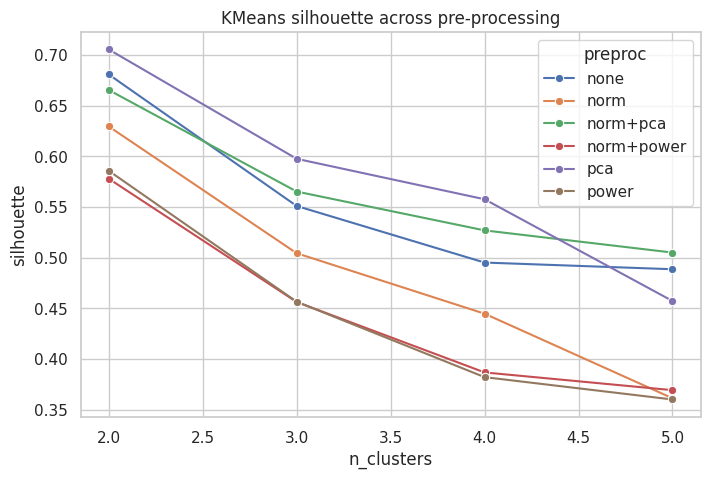

In [5]:
# Example: silhouette by algorithm & cluster count
plt.figure(figsize=(8,5))
sns.lineplot(
    data=res_df.query("algorithm=='KMeans'"),
    x="n_clusters", y="silhouette", hue="preproc", marker="o")
plt.title("KMeans silhouette across pre-processing")
plt.show()
